In [8]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import absplot as absplot

%matplotlib inline

Example 1

In [5]:
###################################################################################
# prepare test data (mimicking Extended Data Fig. 3 in Nature, 616, 696 (2023).)
###################################################################################
hb = 0.65821  # Dirac constant, eV•fs unit
tmin = -150  # fs unit
tmax = 150  # fs unit
n_t = 100
delay_time = np.linspace(tmin, tmax, n_t)  # fs unit
dt = delay_time[1] - delay_time[0]
kmin = -0.18  # k^-1 unit
kmax = 0.18  # k^-1 unit
n_k = 100

momentum = np.linspace(kmin, kmax, n_t)
momentum_peak = 0.05 * np.exp(-delay_time ** 2 / (2 * 42.464 ** 2)) * np.cos(2 * np.pi * delay_time / 40)  # k^-1 unit
Efield = hb * 1e+2 * np.gradient(momentum_peak)  # MV/cm unit

np.random.seed(42)
momentum_peak_exp = momentum_peak + np.random.normal(0, 0.01 * np.abs(momentum_peak) / np.abs(np.max(momentum_peak)),
                                                     size=len(delay_time))
momentum_width_exp = 0.05 + np.random.normal(0, 0.001, size=len(delay_time))

Efield_exp = hb * 1e+2 * np.gradient(momentum_peak_exp)  # MV/cm unit
freq = np.fft.fftshift(np.fft.fftfreq(len(delay_time), dt)) * 1000  # THz unit
Efield_fft = np.fft.fftshift(np.fft.fft(Efield_exp)) * (2.0 / len(delay_time))

spectrogram = 1e+6 * np.exp(-(momentum[:, np.newaxis] - momentum_peak_exp[np.newaxis, :]) ** 2
                            / (2 * momentum_width_exp[np.newaxis, :]) ** 2)

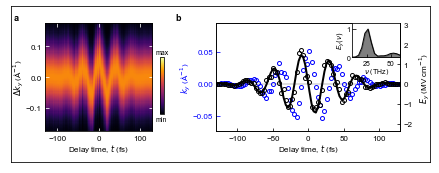

In [16]:
matplotlib.rcParams['font.family'] = 'Arial'
mainframe = absplot.MainFrame(width=148, height=55)
mainframe.ax.set_axis_on()  # show the mainframe background

# global figure parameters
tmin_plot = -130  # fs unit
tmax_plot = 130  # fs unit
kmin_plot = -0.175  # k^-1 unit
kmax_plot = 0.175  # k^-1 unit
ticks_color = 'white'
fontsize_main = 8
fontsize_colorbar = 7
fontsize_symbol = 9
ticks_xpad = 4
ticks_ypad = 3

#######################################################################################################################
# Plot structure 1 (raw streaking images)
#######################################################################################################################
# create empty frame for this structure
eframe1 = absplot.EmptyFrame(mainframe=mainframe, left=1, bottom=1, width=55, height=50)
# eframe1.visualize_frame()

# create plot frames
pframe1 = absplot.PlotFrame(mainframe=mainframe, parentframe=eframe1,
                            left=11, bottom=10, width=38, height=38)
pframe1.modify_ticks(ticks_fontsize=fontsize_main, ticks_color=ticks_color,
                     ticks_label_xpad=ticks_xpad, ticks_label_ypad=ticks_ypad)

# assign image data
extent = [tmin, tmax, kmin, kmax]
pframe1.assign_image(spectrogram, extent=extent,
                     xmin=tmin_plot, xmax=tmax_plot, ymin=kmin_plot, ymax=kmax_plot,
                     colormap='inferno', clim=[0, 1.35e+6], transpose=False, inversex=False)

# set attributes
pframe1.ax.set_ylabel(r'$\Delta k_{y}$ (Å$^{-1}$)', fontsize=fontsize_main, labelpad=0)
for pframe in [pframe1]:
    pframe.ax.set_xlabel(r'Delay time, $t$ (fs)', fontsize=fontsize_main, labelpad=2)

# add colorbar
pframe1.add_colorbar(cleft=40.5, cbottom=6, cwidth=1.5, cheight=20)
pframe1.modify_colorbar(ticks_fontsize=fontsize_main, ticks_color=ticks_color, show_ticks=False)
pframe1.cax.text(0.5, 1.05, 'max', transform=pframe1.cax.transAxes, fontsize=fontsize_colorbar,
                 horizontalalignment='center')
pframe1.cax.text(0.5, -0.13, 'min', transform=pframe1.cax.transAxes, fontsize=fontsize_colorbar,
                 horizontalalignment='center')
pframe1.fix_yaxis_interval(0.1)

#######################################################################################################################
# End of Plot structure 1
#######################################################################################################################


#######################################################################################################################
# Plot structure 2 (extracted waveforms)
#######################################################################################################################
# create empty frame for this structure
eframe2 = absplot.EmptyFrame(mainframe=mainframe, left=60, bottom=1, width=88, height=50)
# eframe2.visualize_frame()

# create plot frames
img_left = 12.5
img_bottom = 10
img_width = 65
img_height = 38
pframe2 = absplot.PlotFrame(mainframe=mainframe, parentframe=eframe2,
                            left=img_left, bottom=img_bottom, width=img_width, height=img_height)
pframe2.modify_ticks(ticks_fontsize=fontsize_main, ticks_color='black',
                     ticks_label_xpad=ticks_xpad, ticks_label_ypad=ticks_ypad,
                     reflect_top=False, reflect_right=False)
pframe2.add_right_axis(ticks_fontsize=fontsize_main, ticks_label_ypad=ticks_ypad)

inset_width = 17
inset_height = 12
pframe2_inset = absplot.PlotFrame(mainframe=mainframe, parentframe=eframe2,
                                  left=img_left + img_width - inset_width,
                                  bottom=img_bottom + img_height - inset_height,
                                  width=inset_width, height=inset_height)
pframe2_inset.modify_ticks(ticks_fontsize=fontsize_main - 1, ticks_color='black',
                           ticks_label_xpad=3, ticks_label_ypad=2,
                           reflect_top=False, reflect_right=False)

# set plot range
pframe2.ax.set_xlim(tmin_plot, tmax_plot)
pframe2.ax.set_ylim(-np.max(np.abs(momentum_peak_exp)) * 1.4, np.max(np.abs(momentum_peak_exp)) * 1.8)
pframe2.ax_right.set_ylim(-np.max(np.abs(Efield_exp)) * 1.4, np.max(np.abs(Efield_exp)) * 1.8)
pframe2_inset.ax.set_xlim(10, 60)
pframe2_inset.ax.set_ylim(0, 1.2)

# plot data
pframe2.ax.plot(delay_time, momentum_peak_exp, color='blue', lw=0, marker='o', ms=4, markerfacecolor='none')
pframe2.ax_right.plot(delay_time, Efield_exp, color='black', lw=0, marker='o', ms=4, markerfacecolor='none')
pframe2.ax_right.plot(delay_time, Efield, color='black', lw=2, markerfacecolor='none')
pframe2_inset.ax.plot(freq, np.abs(Efield_fft) / np.max(np.abs(Efield_fft)), color='black', lw=1)
pframe2_inset.ax.fill_between(freq, np.abs(Efield_fft) / np.max(np.abs(Efield_fft)), 0, color='black', alpha=0.5)

# set other attributes
pframe2.ax.set_xlabel(r'Delay time, $t$ (fs)', fontsize=fontsize_main, labelpad=2)
pframe2.ax.set_ylabel(r'${k}_{y}$ (Å$^{-1}$)', fontsize=fontsize_main, labelpad=0)
pframe2.ax_right.set_ylabel(r'$E_y$ (MV cm$^{-1}$)', fontsize=fontsize_main, labelpad=5)
pframe2.ax.tick_params(axis='y', colors='blue')
pframe2.ax.yaxis.label.set_color('blue')
pframe2_inset.ax.set_xlabel(r'$\nu$ (THz)', fontsize=fontsize_main - 1, labelpad=0)
pframe2_inset.ax.set_ylabel(r'$E_y(\nu)$', fontsize=fontsize_main - 1, labelpad=-1)
pframe2.ax.hlines(0.0, delay_time[0], delay_time[-1], color='black', lw=0.25)
pframe2.fix_yaxis_interval(0.05)

#######################################################################################################################
# End of Plot structure 2
#######################################################################################################################


#######################################################################################################################
# Figure symbols
#######################################################################################################################

mainframe.ax.text(1, 50, 'a', weight='bold', fontsize=fontsize_symbol)
mainframe.ax.text(58, 50, 'b', weight='bold', fontsize=fontsize_symbol)

#######################################################################################################################
# export image files
#######################################################################################################################

plt.savefig('figures/example1.png', dpi=160)

plt.show()